In [13]:
!rm -rf dataset
!rmdir experiments
!mkdir dataset
!mkdir experiments
!unzip filament-segmentation-2026.zip -d dataset

Archive:  filament-segmentation-2026.zip
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110120105534Ch.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110130110334Ch.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110214175414Mh.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110329082654Uh.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110408083214Th.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110424064534Lh.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110429120534Ch.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110529063154Uh.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110531070514Th.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110603123034Ch.jpeg  
  inflating: dataset/MAGFiLO_1.0_Kaggle_2026/test/test_images/20110706164014Mh.jpeg  
  inflating: 

# Solar Filament Segmentation Challenge 2026

- **Autore:** Francesco Peluso [`IE22700088` | f.peluso29@studenti.unisa.it]
- **Corso:** Machine Learning A.A. 2025/26 — Laurea Magistrale in Ingegneria Informatica, DIEM, Università degli Studi di Salerno

## Descrizione del problema

L'obiettivo è identificare i filamenti nelle immagini solari formulando il problema come **segmentazione semantica binaria**: ogni pixel deve essere classificato come sfondo (0) o filamento (1). I filamenti sono strutture sottili e irregolari, spesso poco contrastate rispetto alla superficie solare; inoltre, occupano una porzione ridotta dell'immagine e producono un forte sbilanciamento tra le classi.

La qualità della segmentazione sarà valutata principalmente con il **coefficiente di Dice**, che misura la sovrapposizione tra la maschera predetta $P$ e la ground truth $G$:

$$
\mathrm{Dice}(P,G)=\frac{2|P\cap G|}{|P|+|G|}.
$$

## Approccio proposto

Come punto di partenza useremo una **U-Net**. L'encoder estrae caratteristiche progressivamente più astratte, il decoder ricostruisce la mappa di segmentazione e le *skip connections* trasferiscono informazioni spaziali ad alta risoluzione. Queste ultime sono particolarmente utili per preservare forma, contorni e continuità dei filamenti più sottili. L'uscita avrà un solo canale e sarà convertita in probabilità mediante una funzione sigmoide.

## Caricamento del dataset

Le annotazioni sono memorizzate in formato COCO: ogni record in `images` identifica un'annotazione indipendente di una determinata osservazione, mentre `annotations` contiene i poligoni dei singoli filamenti. Poiché la stessa immagine può essere stata annotata da più annotatori, un file JPEG può comparire con più `image_id`. Conserviamo queste ground truth come campioni distinti, ma effettuiamo lo split per **nome del file**, così la stessa osservazione non può comparire in partizioni diverse.

In [14]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

SEED = 22
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15

# Funziona sia avviando Jupyter dalla root, sia da una sua sottocartella.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "dataset").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Cartella 'dataset' non trovata nella directory corrente o nei suoi parent.")

TRAIN_DIR = PROJECT_ROOT / "dataset" / "MAGFiLO_1.0_Kaggle_2026" / "train"
TRAIN_IMAGES_DIR = TRAIN_DIR / "train_images"
ANNOTATIONS_PATH = TRAIN_DIR / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
OFFICIAL_TEST_IMAGES_DIR = PROJECT_ROOT / "dataset" / "test" / "test_images"

print(f"Project root: {PROJECT_ROOT}")

Project root: /content


In [15]:
with ANNOTATIONS_PATH.open(encoding="utf-8") as file:
    coco = json.load(file)

annotations_by_image_id = defaultdict(list)
for annotation in coco["annotations"]:
    annotations_by_image_id[annotation["image_id"]].append(annotation)

samples = []
for image_info in coco["images"]:
    image_path = TRAIN_IMAGES_DIR / image_info["file_name"]
    samples.append(
        {
            "image_id": image_info["id"],
            "file_name": image_info["file_name"],
            "image_path": image_path,
            "width": image_info["width"],
            "height": image_info["height"],
            "annotations": annotations_by_image_id[image_info["id"]],
        }
    )

missing_images = [sample["image_path"] for sample in samples if not sample["image_path"].is_file()]
if missing_images:
    raise FileNotFoundError(f"Mancano {len(missing_images)} immagini; prima: {missing_images[0]}")

records_per_file = Counter(sample["file_name"] for sample in samples)
official_test_count = len(list(OFFICIAL_TEST_IMAGES_DIR.glob("*.jpeg")))

print(f"File JPEG annotati univoci: {len(records_per_file)}")
print(f"Record COCO (immagine + annotatore): {len(samples)}")
print(f"Poligoni di filamenti: {len(coco['annotations'])}")
print(f"Record per file: {dict(sorted(Counter(records_per_file.values()).items()))}")
print(f"Immagini del test ufficiale Kaggle, senza ground truth: {official_test_count}")

File JPEG annotati univoci: 707
Record COCO (immagine + annotatore): 1154
Poligoni di filamenti: 8199
Record per file: {1: 411, 2: 145, 3: 151}
Immagini del test ufficiale Kaggle, senza ground truth: 0


## Split in training, validation e test

Dividiamo le 707 osservazioni annotate in modo riproducibile nelle proporzioni **70% / 15% / 15%**. Questo test set interno serve per la valutazione finale del modello e non va confuso con `dataset/test/test_images`, che è il test ufficiale Kaggle privo di ground truth. Tutti i record prodotti da annotatori diversi per la stessa immagine rimangono nella medesima partizione.

In [16]:
def split_samples_by_file(
    samples,
    train_fraction=TRAIN_FRACTION,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
):
    if not 0 < train_fraction < 1 or not 0 < validation_fraction < 1:
        raise ValueError("Le frazioni devono essere comprese tra 0 e 1.")
    if train_fraction + validation_fraction >= 1:
        raise ValueError("La somma delle frazioni di training e validation deve essere minore di 1.")

    file_names = sorted({sample["file_name"] for sample in samples})
    random.Random(seed).shuffle(file_names)

    train_end = int(len(file_names) * train_fraction)
    validation_end = train_end + int(len(file_names) * validation_fraction)
    file_names_by_split = {
        "train": set(file_names[:train_end]),
        "validation": set(file_names[train_end:validation_end]),
        "test": set(file_names[validation_end:]),
    }

    samples_by_split = {
        split_name: [sample for sample in samples if sample["file_name"] in split_file_names]
        for split_name, split_file_names in file_names_by_split.items()
    }
    return samples_by_split, file_names_by_split


samples_by_split, file_names_by_split = split_samples_by_file(samples)

assert file_names_by_split["train"].isdisjoint(file_names_by_split["validation"])
assert file_names_by_split["train"].isdisjoint(file_names_by_split["test"])
assert file_names_by_split["validation"].isdisjoint(file_names_by_split["test"])
assert sum(map(len, file_names_by_split.values())) == len({s["file_name"] for s in samples})

for split_name in ("train", "validation", "test"):
    n_files = len(file_names_by_split[split_name])
    n_records = len(samples_by_split[split_name])
    n_polygons = sum(len(sample["annotations"]) for sample in samples_by_split[split_name])
    print(f"{split_name:10s}: {n_files:3d} file, {n_records:3d} record COCO, {n_polygons:4d} poligoni")

train     : 494 file, 806 record COCO, 5856 poligoni
validation: 106 file, 169 record COCO, 1144 poligoni
test      : 107 file, 179 record COCO, 1199 poligoni


## Costruzione delle maschere binarie

Ogni annotazione descrive un filamento mediante uno o più poligoni COCO. La funzione seguente rasterizza tutti i poligoni associati a un `image_id` in una singola maschera binaria. Immagini e maschere vengono caricate **on demand**, evitando di conservare in RAM l'intero dataset ad alta risoluzione.

Esempio: 20140609195854Bh.jpeg (040301-20140609195854Bh)
Immagine: shape=(2048, 2048, 3), dtype=uint8
Maschera:  shape=(2048, 2048), dtype=uint8, valori=[0 1]
Pixel di filamento: 18,170


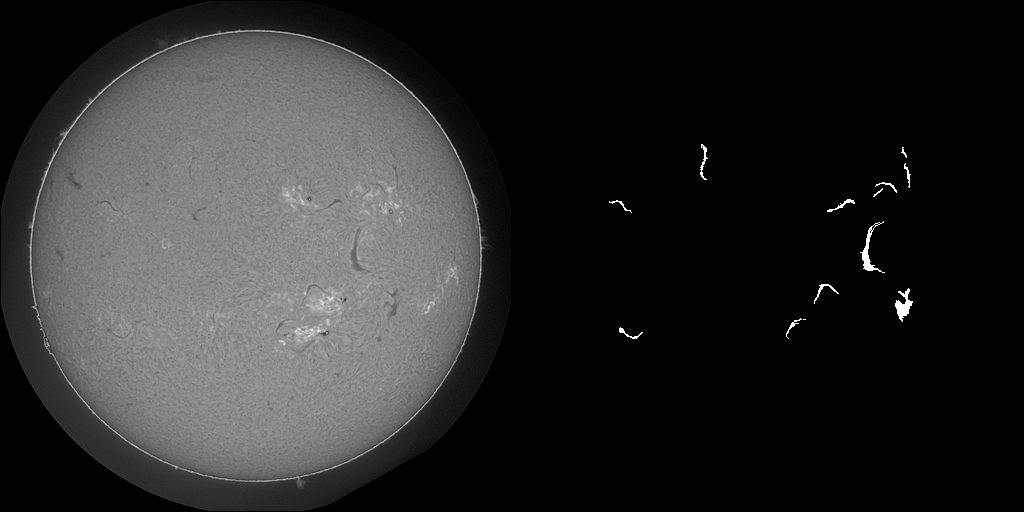

In [17]:
def annotations_to_binary_mask(width, height, annotations):
    mask = Image.new("L", (width, height), 0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        for polygon in annotation.get("segmentation", []):
            if len(polygon) < 6:
                continue
            points = [(polygon[index], polygon[index + 1]) for index in range(0, len(polygon), 2)]
            drawer.polygon(points, fill=1)

    return np.asarray(mask, dtype=np.uint8)


def load_sample(sample):
    with Image.open(sample["image_path"]) as image_file:
        image = np.asarray(image_file.convert("RGB"))

    mask = annotations_to_binary_mask(
        width=sample["width"],
        height=sample["height"],
        annotations=sample["annotations"],
    )
    if image.shape[:2] != mask.shape:
        raise ValueError(f"Dimensioni non coerenti per {sample['file_name']}: {image.shape[:2]} != {mask.shape}")
    return image, mask


example_sample = samples_by_split["train"][0]
example_image, example_mask = load_sample(example_sample)

print(f"Esempio: {example_sample['file_name']} ({example_sample['image_id']})")
print(f"Immagine: shape={example_image.shape}, dtype={example_image.dtype}")
print(f"Maschera:  shape={example_mask.shape}, dtype={example_mask.dtype}, valori={np.unique(example_mask)}")
print(f"Pixel di filamento: {example_mask.sum():,}")

# Visualizzazione affiancata dell'immagine e della relativa ground truth.
preview_size = (512, 512)
image_preview = Image.fromarray(example_image).resize(preview_size)
mask_preview = Image.fromarray(example_mask * 255).resize(preview_size, resample=Image.Resampling.NEAREST)
side_by_side_preview = Image.new("RGB", (preview_size[0] * 2, preview_size[1]))
side_by_side_preview.paste(image_preview, (0, 0))
side_by_side_preview.paste(mask_preview.convert("RGB"), (preview_size[0], 0))
side_by_side_preview  # Jupyter visualizza automaticamente l'ultima espressione della cella.

## Pipeline PyTorch

Le osservazioni H-alpha sono immagini in scala di grigi a risoluzione $2048\times2048$. Negli esperimenti 01-03 venivano ridimensionate a $512\times512$; da questo esperimento il training usa **crop casuali $512\times512$ alla risoluzione nativa**, per non perdere i filamenti più sottili che il resize tende a cancellare. Poiché i filamenti occupano una frazione minima dell'immagine, nell'80% dei casi il crop è campionato tra quelli che contengono almeno un pixel di filamento (massimo 10 tentativi); il restante 20% è casuale puro e include sfondo, bordo del disco e rumore.

Durante il training applichiamo rotazioni di multipli di 90° e riflessioni sia all'immagine sia alla maschera. Validation e test usano l'inferenza a tasselli descritta più sotto. Il canale grayscale è replicato su tre canali (forma `3 × H × W`), perché l'encoder ResNet18 attende un ingresso RGB.

In [18]:
import csv
import platform
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import ImageOps
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

IMAGE_SIZE = (512, 512)
BATCH_SIZE = 2
IN_CHANNELS = 3  # L'encoder ResNet18 attende un ingresso RGB: replichiamo il canale grayscale.
NUM_WORKERS = 0  # Impostazione portabile per l'esecuzione dentro Jupyter.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch: {torch.__version__} | Device: {device}")

PyTorch: 2.11.0+cu128 | Device: cuda


In [19]:
class SegmentationTransform:
    def __init__(self, size=IMAGE_SIZE, augment=False, in_channels=1):
        self.size = size
        self.augment = augment
        self.in_channels = in_channels

    def __call__(self, image, mask):
        # Le JPEG H-alpha sono monocromatiche; manteniamo un solo canale.
        image = Image.fromarray(image).convert("L")
        mask = Image.fromarray(mask)

        # PIL usa (larghezza, altezza), mentre IMAGE_SIZE è (altezza, larghezza).
        resize_size = (self.size[1], self.size[0])
        image = image.resize(resize_size, resample=Image.Resampling.BILINEAR)
        mask = mask.resize(resize_size, resample=Image.Resampling.NEAREST)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                image = ImageOps.mirror(image)
                mask = ImageOps.mirror(mask)
            if torch.rand(1).item() < 0.5:
                image = ImageOps.flip(image)
                mask = ImageOps.flip(mask)

            rotation = int(torch.randint(0, 4, (1,)).item())
            rotation_ops = (
                None,
                Image.Transpose.ROTATE_90,
                Image.Transpose.ROTATE_180,
                Image.Transpose.ROTATE_270,
            )
            if rotation_ops[rotation] is not None:
                image = image.transpose(rotation_ops[rotation])
                mask = mask.transpose(rotation_ops[rotation])

        image_array = np.array(image, dtype=np.float32, copy=True) / 255.0
        mask_array = np.array(mask, dtype=np.float32, copy=True)
        mask_array = (mask_array > 0).astype(np.float32)

        image_tensor = torch.from_numpy(image_array).unsqueeze(0)
        if self.in_channels == 3:
            image_tensor = image_tensor.repeat(3, 1, 1)
        mask_tensor = torch.from_numpy(mask_array).unsqueeze(0)
        return image_tensor, mask_tensor


class SolarFilamentDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image, mask = load_sample(sample)
        image, mask = self.transform(image, mask)
        return {
            "image": image,
            "mask": mask,
            "file_name": sample["file_name"],
            "image_id": sample["image_id"],
        }


class RandomCropTransform:
    def __init__(self, crop_size=IMAGE_SIZE, augment=False, in_channels=1,
                 filament_probability=0.8, max_attempts=10):
        self.crop_size = crop_size
        self.augment = augment
        self.in_channels = in_channels
        self.filament_probability = filament_probability
        self.max_attempts = max_attempts

    def __call__(self, image, mask):
        # Crop casuale alla risoluzione nativa; con probabilità 0,8 il crop contiene filamento.
        crop_height, crop_width = self.crop_size
        height, width = mask.shape
        if height < crop_height or width < crop_width:
            raise ValueError(f"Immagine {(height, width)} più piccola del crop {self.crop_size}.")

        want_filament = torch.rand(1).item() < self.filament_probability
        top = left = 0
        for _ in range(self.max_attempts):
            top = int(torch.randint(0, height - crop_height + 1, (1,)).item())
            left = int(torch.randint(0, width - crop_width + 1, (1,)).item())
            if not want_filament or mask[top:top + crop_height, left:left + crop_width].sum() > 0:
                break

        image = Image.fromarray(image[top:top + crop_height, left:left + crop_width]).convert("L")
        mask = Image.fromarray(mask[top:top + crop_height, left:left + crop_width])

        if self.augment:
            if torch.rand(1).item() < 0.5:
                image = ImageOps.mirror(image)
                mask = ImageOps.mirror(mask)
            if torch.rand(1).item() < 0.5:
                image = ImageOps.flip(image)
                mask = ImageOps.flip(mask)

            rotation = int(torch.randint(0, 4, (1,)).item())
            rotation_ops = (
                None,
                Image.Transpose.ROTATE_90,
                Image.Transpose.ROTATE_180,
                Image.Transpose.ROTATE_270,
            )
            if rotation_ops[rotation] is not None:
                image = image.transpose(rotation_ops[rotation])
                mask = mask.transpose(rotation_ops[rotation])

        image_array = np.array(image, dtype=np.float32, copy=True) / 255.0
        mask_array = np.array(mask, dtype=np.float32, copy=True)
        mask_array = (mask_array > 0).astype(np.float32)

        image_tensor = torch.from_numpy(image_array).unsqueeze(0)
        if self.in_channels == 3:
            image_tensor = image_tensor.repeat(3, 1, 1)
        mask_tensor = torch.from_numpy(mask_array).unsqueeze(0)
        return image_tensor, mask_tensor

In [20]:
# Training: crop casuali 512x512 alla risoluzione nativa (80% contenenti filamento).
train_dataset = SolarFilamentDataset(
    samples_by_split["train"],
    transform=RandomCropTransform(augment=True, in_channels=IN_CHANNELS),
)

# Validation e test: campioni grezzi, valutati con inferenza a tasselli (cella seguente).
validation_samples = samples_by_split["validation"]
test_samples = samples_by_split["test"]

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)

example_batch = next(iter(train_loader))
print(f"Batch immagini: {tuple(example_batch['image'].shape)}")
print(f"Batch maschere: {tuple(example_batch['mask'].shape)}")
print(f"Valori maschera: {torch.unique(example_batch['mask']).tolist()}")

Batch immagini: (2, 3, 512, 512)
Batch maschere: (2, 1, 512, 512)
Valori maschera: [0.0, 1.0]


## Inferenza a tasselli sulla risoluzione nativa

Validation e test non possono usare il resize a $512\times512$: il modello è addestrato su crop alla risoluzione nativa e vedrebbe un ingresso fuori distribuzione. Ogni immagine $2048\times2048$ è divisa in una griglia $4\times4$ di tasselli da $512\times512$, le mappe di probabilità sono ricomposte a piena risoluzione e poi ridotte a $512\times512$ per il **confronto diretto con gli esperimenti 01-03** (stessa ground truth ridimensionata). Il Dice è calcolato a entrambe le risoluzioni.

In [21]:
def image_to_tensor(image_array, in_channels=IN_CHANNELS):
    image = Image.fromarray(image_array).convert("L")
    array = np.array(image, dtype=np.float32, copy=True) / 255.0
    tensor = torch.from_numpy(array).unsqueeze(0)
    if in_channels == 3:
        tensor = tensor.repeat(3, 1, 1)
    return tensor


@torch.inference_mode()
def predict_full_image_probability(model, image, device, tile_size=IMAGE_SIZE, batch_size=8):
    model.eval()
    tile_height, tile_width = tile_size
    height, width = image.shape[:2]
    if height % tile_height or width % tile_width:
        raise ValueError("La griglia di tasselli deve coprire esattamente l'immagine.")

    positions = [
        (top, left)
        for top in range(0, height, tile_height)
        for left in range(0, width, tile_width)
    ]
    tiles = [
        image_to_tensor(image[top:top + tile_height, left:left + tile_width])
        for top, left in positions
    ]

    probability_map = np.zeros((height, width), dtype=np.float32)
    for start in range(0, len(tiles), batch_size):
        batch = torch.stack(tiles[start:start + batch_size]).to(device)
        probabilities = torch.sigmoid(model(batch)).cpu().numpy()
        for (top, left), tile_probability in zip(positions[start:start + batch_size], probabilities):
            probability_map[top:top + tile_height, left:left + tile_width] = tile_probability[0]
    return probability_map


def resize_probability_map(probability_map, size=IMAGE_SIZE):
    tensor = torch.from_numpy(probability_map)[None, None]
    resized = F.interpolate(tensor, size=size, mode="bilinear", align_corners=False)
    return resized[0, 0].numpy()


def resize_binary_mask(mask, size=IMAGE_SIZE):
    image = Image.fromarray((mask > 0).astype(np.uint8))
    resized = image.resize((size[1], size[0]), resample=Image.Resampling.NEAREST)
    return (np.array(resized, dtype=np.float32) > 0).astype(np.float32)


def dice_from_probabilities(probabilities, target, threshold, epsilon=1e-6):
    prediction = (probabilities >= threshold).astype(np.float32)
    intersection = (prediction * target).sum()
    denominator = prediction.sum() + target.sum()
    return float((2.0 * intersection + epsilon) / (denominator + epsilon))


def bce_dice_loss_from_probabilities(probabilities, target, epsilon=1e-6):
    clipped = np.clip(probabilities, epsilon, 1.0 - epsilon)
    bce = -(target * np.log(clipped) + (1.0 - target) * np.log(1.0 - clipped)).mean()
    intersection = (clipped * target).sum()
    soft_dice = (2.0 * intersection + epsilon) / (clipped.sum() + target.sum() + epsilon)
    return float(0.5 * bce + 0.5 * (1.0 - soft_dice))


@torch.inference_mode()
def evaluate_tiled(model, samples, device, thresholds=(0.5,), description="Valutazione a tasselli"):
    threshold_array = np.asarray(thresholds, dtype=np.float32)
    dice_native_sum = np.zeros(len(threshold_array))
    dice_resized_sum = np.zeros(len(threshold_array))
    total_loss = 0.0

    for sample in tqdm(samples, desc=description, unit="img", leave=False):
        image, mask = load_sample(sample)
        probability_map = predict_full_image_probability(model, image, device)

        resized_probabilities = resize_probability_map(probability_map)
        resized_mask = resize_binary_mask(mask)
        total_loss += bce_dice_loss_from_probabilities(resized_probabilities, resized_mask)

        for index, threshold in enumerate(threshold_array):
            dice_native_sum[index] += dice_from_probabilities(
                probability_map, mask.astype(np.float32), threshold
            )
            dice_resized_sum[index] += dice_from_probabilities(
                resized_probabilities, resized_mask, threshold
            )

    sample_count = len(samples)
    return {
        "loss": total_loss / sample_count,
        "thresholds": threshold_array,
        "dice_native": dice_native_sum / sample_count,
        "dice_resized": dice_resized_sum / sample_count,
    }

## U-Net baseline

La rete seguente usa quattro livelli encoder–decoder e 16 filtri nel primo livello. È volutamente compatta per ottenere rapidamente una baseline e contenere l'uso di memoria. L'ultimo strato restituisce i **logit**: la sigmoide viene applicata dalla loss o in fase di inferenza, non dentro `forward`.

In [22]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat((skip, x), dim=1))


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c = base_channels
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder_1 = DoubleConv(in_channels, c)
        self.encoder_2 = DoubleConv(c, c * 2)
        self.encoder_3 = DoubleConv(c * 2, c * 4)
        self.encoder_4 = DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)
        self.decoder_4 = DecoderBlock(c * 16, c * 8, c * 8)
        self.decoder_3 = DecoderBlock(c * 8, c * 4, c * 4)
        self.decoder_2 = DecoderBlock(c * 4, c * 2, c * 2)
        self.decoder_1 = DecoderBlock(c * 2, c, c)
        self.output = nn.Conv2d(c, out_channels, kernel_size=1)

    def forward(self, x):
        skip_1 = self.encoder_1(x)
        skip_2 = self.encoder_2(self.pool(skip_1))
        skip_3 = self.encoder_3(self.pool(skip_2))
        skip_4 = self.encoder_4(self.pool(skip_3))
        x = self.bottleneck(self.pool(skip_4))
        x = self.decoder_4(x, skip_4)
        x = self.decoder_3(x, skip_3)
        x = self.decoder_2(x, skip_2)
        x = self.decoder_1(x, skip_1)
        return self.output(x)

## U-Net con encoder ResNet18 pre-addestrato

Dall'esperimento 03 in poi sostituiamo l'encoder costruito da zero con una **ResNet18 pre-addestrata su ImageNet**. L'ipotesi: le feature visive apprese su milioni di immagini (bordi, texture, strutture locali) sono un buon punto di partenza anche per le osservazioni solari e riducono i dati necessari per addestrare l'encoder, che è la parte più profonda e costosa della rete. Il decoder riusa i blocchi della U-Net baseline, con skip connections dagli stadi della ResNet.

ResNet18 attende un ingresso a tre canali: replichiamo il canale grayscale senza modificare i pesi del primo strato convoluzionale. Tutti i pesi vengono aggiornati durante il training (*fine-tuning*), con un learning rate ridotto ($10^{-4}$ invece di $10^{-3}$) per non distruggere le feature pre-addestrate.

In [23]:
from torchvision.models import ResNet18_Weights, resnet18


class ResNet18UNet(nn.Module):
    def __init__(self, out_channels=1, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        encoder = resnet18(weights=weights)

        self.stem = nn.Sequential(encoder.conv1, encoder.bn1, encoder.relu)
        self.maxpool = encoder.maxpool
        self.encoder_1 = encoder.layer1  # 64 canali, risoluzione 1/4
        self.encoder_2 = encoder.layer2  # 128 canali, risoluzione 1/8
        self.encoder_3 = encoder.layer3  # 256 canali, risoluzione 1/16
        self.encoder_4 = encoder.layer4  # 512 canali, risoluzione 1/32

        self.decoder_4 = DecoderBlock(512, 256, 256)
        self.decoder_3 = DecoderBlock(256, 128, 128)
        self.decoder_2 = DecoderBlock(128, 64, 64)
        self.decoder_1 = DecoderBlock(64, 64, 64)
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = DoubleConv(32, 32)
        self.output = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        skip_stem = self.stem(x)
        skip_1 = self.encoder_1(self.maxpool(skip_stem))
        skip_2 = self.encoder_2(skip_1)
        skip_3 = self.encoder_3(skip_2)
        x = self.encoder_4(skip_3)
        x = self.decoder_4(x, skip_3)
        x = self.decoder_3(x, skip_2)
        x = self.decoder_2(x, skip_1)
        x = self.decoder_1(x, skip_stem)
        x = self.final_conv(self.final_up(x))
        return self.output(x)

## Loss e metrica

Per gestire lo sbilanciamento tra sfondo e filamenti combiniamo `BCEWithLogitsLoss`, stabile numericamente, e **soft Dice loss**. Per il monitoraggio riportiamo invece il Dice sulle maschere binarie ottenute con soglia 0,5.

In [24]:
def soft_dice_score(logits, targets, epsilon=1e-6):
    probabilities = torch.sigmoid(logits)
    dimensions = (1, 2, 3)
    intersection = (probabilities * targets).sum(dim=dimensions)
    denominator = probabilities.sum(dim=dimensions) + targets.sum(dim=dimensions)
    return ((2.0 * intersection + epsilon) / (denominator + epsilon)).mean()


def binary_dice_score(logits, targets, threshold=0.5, epsilon=1e-6):
    predictions = (torch.sigmoid(logits) >= threshold).float()
    dimensions = (1, 2, 3)
    intersection = (predictions * targets).sum(dim=dimensions)
    denominator = predictions.sum(dim=dimensions) + targets.sum(dim=dimensions)
    return ((2.0 * intersection + epsilon) / (denominator + epsilon)).mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = 1.0 - soft_dice_score(logits, targets)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


# Esperimenti 01-02 (U-Net addestrata da zero):
# model = UNet().to(device)
model = ResNet18UNet(pretrained=True).to(device)
criterion = BCEDiceLoss()

LEARNING_RATE = 1e-4  # Ridotto per il fine-tuning: preserva le feature pre-addestrate.
WEIGHT_DECAY = 1e-4

# Exp 01: torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# Exp 02: torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
with torch.no_grad():
    sanity_images = example_batch["image"].to(device)
    sanity_masks = example_batch["mask"].to(device)
    sanity_logits = model(sanity_images)
    sanity_loss = criterion(sanity_logits, sanity_masks)

print(f"Parametri addestrabili: {parameter_count:,}")
print(f"Output U-Net: {tuple(sanity_logits.shape)}")
print(f"Loss iniziale: {sanity_loss.item():.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 234MB/s]


Parametri addestrabili: 14,343,425
Output U-Net: (2, 1, 512, 512)
Loss iniziale: 0.9135


## Tracciamento dell'esperimento

Ogni configurazione usa una cartella dedicata in `experiments/`. Prima di avviare un nuovo esperimento occorre cambiare `EXPERIMENT_ID`; rieseguire lo stesso ID aggiorna i file della medesima esecuzione. Cronologia e checkpoint migliore vengono salvati durante il training, così i risultati già completati sopravvivono anche a un'interruzione.

In [25]:
EXPERIMENT_ID = "04"
EPOCHS = 20
EARLY_STOPPING_PATIENCE = 8
EARLY_STOPPING_MIN_DELTA = 1e-3
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / EXPERIMENT_ID
METRICS_DIR = EXPERIMENT_DIR / "metrics"
PLOTS_DIR = EXPERIMENT_DIR / "plots"
CHECKPOINTS_DIR = EXPERIMENT_DIR / "checkpoints"

for directory in (EXPERIMENT_DIR, METRICS_DIR, PLOTS_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def save_json(data, path):
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")


def save_history(history, metrics_dir=METRICS_DIR):
    save_json(history, metrics_dir / "history.json")
    if history:
        with (metrics_dir / "history.csv").open("w", newline="", encoding="utf-8") as file:
            writer = csv.DictWriter(file, fieldnames=history[0].keys())
            writer.writeheader()
            writer.writerows(history)


experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "model": "U-Net con encoder ResNet18 pre-addestrato (ImageNet)",
    "description": "Training su crop 512x512 alla risoluzione nativa; inferenza a tasselli 4x4",
    "in_channels": 3,
    "encoder": "ResNet18 (ImageNet1K_V1)",
    "trainable_parameters": parameter_count,
    "training_input": "random crop 512x512 nativi, 80% con filamento (max 10 tentativi)",
    "validation_protocol": "griglia 4x4 tasselli 512x512, ricomposizione 2048x2048, Dice a 512x512 e nativo",
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "early_stopping": {
        "monitor": "validation_dice",
        "mode": "max",
        "patience": EARLY_STOPPING_PATIENCE,
        "min_delta": EARLY_STOPPING_MIN_DELTA,
    },
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "loss": "0.5 * BCEWithLogitsLoss + 0.5 * DiceLoss",
    "seed": SEED,
    "split_fractions": {"train": TRAIN_FRACTION, "validation": VALIDATION_FRACTION, "test": 1 - TRAIN_FRACTION - VALIDATION_FRACTION},
    "unique_files_per_split": {name: len(files) for name, files in file_names_by_split.items()},
    "coco_records_per_split": {name: len(records) for name, records in samples_by_split.items()},
    "device": str(device),
    "python_version": sys.version.split()[0],
    "pytorch_version": torch.__version__,
    "platform": platform.platform(),
}
save_json(experiment_config, EXPERIMENT_DIR / "config.json")
save_json(
    {name: sorted(files) for name, files in file_names_by_split.items()},
    EXPERIMENT_DIR / "split_manifest.json",
)
(EXPERIMENT_DIR / "model.txt").write_text(str(model), encoding="utf-8")
print(f"Artefatti dell'esperimento: {EXPERIMENT_DIR}")

Artefatti dell'esperimento: /content/experiments/04


## Ciclo di addestramento

Il ciclo salva su disco il checkpoint corrispondente al Dice di validation migliore, aggiorna la cronologia dopo ogni epoca e ripristina i pesi migliori al termine. L'early stopping monitora il Dice di validation, con pazienza pari a otto epoche. La validation è eseguita a tasselli sulla risoluzione nativa; il Dice monitorato è quello ricalcolato a $512\times512$, confrontabile con gli esperimenti precedenti. Impostare `RUN_TRAINING = True` per avviare il training.

In [26]:
def run_epoch(model, data_loader, criterion, device, optimizer=None, description=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_dice = 0.0
    total_samples = 0

    progress_bar = tqdm(
        data_loader,
        desc=description or ("Training" if is_training else "Validation"),
        unit="batch",
        leave=False,
    )
    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, masks)
            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        batch_dice = binary_dice_score(logits.detach(), masks).item()
        total_dice += batch_dice * batch_size
        total_samples += batch_size
        progress_bar.set_postfix(
            loss=f"{total_loss / total_samples:.4f}",
            dice=f"{total_dice / total_samples:.4f}",
        )

    return {
        "loss": total_loss / total_samples,
        "dice": total_dice / total_samples,
    }


def fit(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    epochs,
    experiment_dir,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
    validation_fn=None,
):
    history = []
    best_validation_dice = -1.0
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0
    early_stopped = False

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            device,
            optimizer,
            description=f"Epoca {epoch:02d}/{epochs} [train]",
        )
        if validation_fn is not None:
            validation_metrics = validation_fn(model)
        else:
            with torch.no_grad():
                validation_metrics = run_epoch(
                    model,
                    validation_loader,
                    criterion,
                    device,
                    description=f"Epoca {epoch:02d}/{epochs} [validation]",
                )

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "validation_loss": validation_metrics["loss"],
            "validation_dice": validation_metrics["dice"],
        })
        save_history(history, experiment_dir / "metrics")

        if validation_metrics["dice"] > best_validation_dice + min_delta:
            best_validation_dice = validation_metrics["dice"]
            best_epoch = epoch
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "validation_loss": validation_metrics["loss"],
                    "validation_dice": validation_metrics["dice"],
                    "experiment_id": experiment_dir.name,
                },
                experiment_dir / "checkpoints" / "best_model.pt",
            )
            save_json(
                {
                    "best_epoch": epoch,
                    "best_validation_dice": best_validation_dice,
                    "monitor": "validation_dice",
                    "patience": patience,
                    "min_delta": min_delta,
                },
                experiment_dir / "metrics" / "best_validation.json",
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f}, Dice {train_metrics['dice']:.4f} | "
            f"val loss {validation_metrics['loss']:.4f}, Dice {validation_metrics['dice']:.4f} | "
            f"senza miglioramenti {epochs_without_improvement}/{patience}"
        )

        if epochs_without_improvement >= patience:
            early_stopped = True
            print(
                f"Early stopping all'epoca {epoch}: nessun miglioramento del Dice di validation "
                f"> {min_delta} nelle ultime {patience} epoche."
            )
            break

    model.load_state_dict(best_state)
    training_summary = {
        "best_epoch": best_epoch,
        "best_validation_dice": best_validation_dice,
        "epochs_completed": len(history),
        "early_stopped": early_stopped,
        "monitor": "validation_dice",
        "patience": patience,
        "min_delta": min_delta,
    }
    save_json(training_summary, experiment_dir / "metrics" / "training_summary.json")
    print(f"Miglior Dice di validation: {best_validation_dice:.4f}")
    return history, training_summary


RUN_TRAINING = True

def validation_fn(model):
    results = evaluate_tiled(
        model, validation_samples, device,
        thresholds=(0.5,), description="Validation a tasselli",
    )
    return {"loss": results["loss"], "dice": float(results["dice_resized"][0])}


if RUN_TRAINING:
    history, training_summary = fit(
        model,
        train_loader,
        None,
        criterion,
        optimizer,
        device,
        epochs=EPOCHS,
        experiment_dir=EXPERIMENT_DIR,
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=EARLY_STOPPING_MIN_DELTA,
        validation_fn=validation_fn,
    )
else:
    history = None
    training_summary = None
    print("Training non avviato: impostare RUN_TRAINING = True quando si è pronti.")

Epoca 01/20 [train]:   0%|          | 0/403 [00:00<?, ?batch/s]

Validation a tasselli:   0%|          | 0/169 [00:00<?, ?img/s]

Epoch 01/20 | train loss 0.7128, Dice 0.3452 | val loss 0.6630, Dice 0.5183 | senza miglioramenti 0/8


Epoca 02/20 [train]:   0%|          | 0/403 [00:00<?, ?batch/s]

Validation a tasselli:   0%|          | 0/169 [00:00<?, ?img/s]

...

Validation a tasselli:   0%|          | 0/169 [00:00<?, ?img/s]

Epoch 19/20 | train loss 0.2523, Dice 0.5769 | val loss 0.2239, Dice 0.5924 | senza miglioramenti 6/8


Epoca 20/20 [train]:   0%|          | 0/403 [00:00<?, ?batch/s]

Validation a tasselli:   0%|          | 0/169 [00:00<?, ?img/s]

Epoch 20/20 | train loss 0.2461, Dice 0.6143 | val loss 0.2111, Dice 0.6093 | senza miglioramenti 0/8
Miglior Dice di validation: 0.6093


## Controlli dell'addestramento

Le celle seguenti vengono eseguite soltanto se esiste `history`, quindi un normale *Run all* con `RUN_TRAINING = False` non produce errori. Controlliamo l'andamento di loss e Dice per individuare underfitting o overfitting.

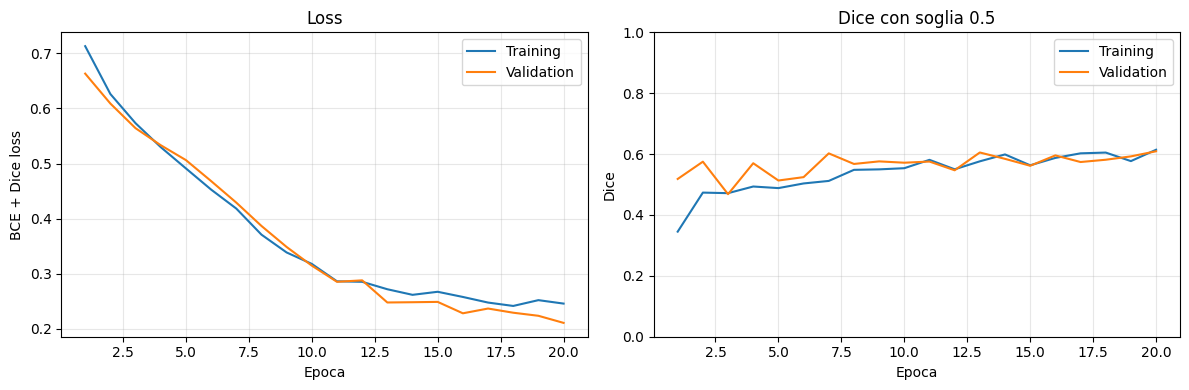

In [27]:
def plot_training_history(history, save_path=None):
    import matplotlib.pyplot as plt

    epochs = [row["epoch"] for row in history]
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, [row["train_loss"] for row in history], label="Training")
    axes[0].plot(epochs, [row["validation_loss"] for row in history], label="Validation")
    axes[0].set(title="Loss", xlabel="Epoca", ylabel="BCE + Dice loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_dice"] for row in history], label="Training")
    axes[1].plot(epochs, [row["validation_dice"] for row in history], label="Validation")
    axes[1].set(title="Dice con soglia 0.5", xlabel="Epoca", ylabel="Dice", ylim=(0, 1))
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    figure.tight_layout()
    if save_path is not None:
        figure.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


if "history" in globals() and history:
    plot_training_history(history, PLOTS_DIR / "training_curves.png")
else:
    print("Curve non disponibili: eseguire prima il training.")

## Controllo qualitativo sulla validation

Confrontiamo immagine, ground truth, probabilità e maschera predetta. Questa visualizzazione usa esclusivamente campioni di validation e mostra anche il Dice del singolo campione.

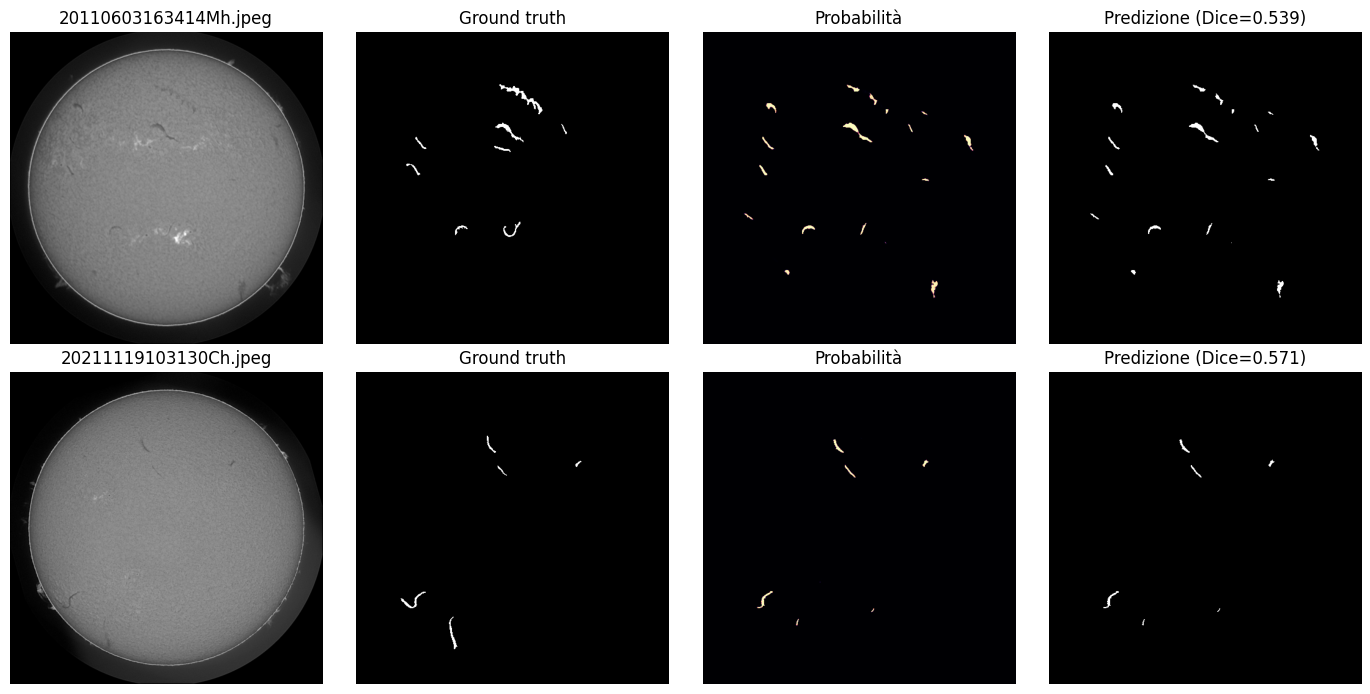

In [28]:
@torch.inference_mode()
def get_prediction_batch(model, data_loader, device):
    model.eval()
    batch = next(iter(data_loader))
    images = batch["image"].to(device)
    logits = model(images)
    return {
        "images": batch["image"].cpu(),
        "masks": batch["mask"].cpu(),
        "probabilities": torch.sigmoid(logits).cpu(),
        "file_names": batch["file_name"],
    }


def show_segmentation_predictions(prediction_batch, threshold=0.5, max_samples=2, save_path=None):
    import matplotlib.pyplot as plt

    sample_count = min(max_samples, len(prediction_batch["file_names"]))
    figure, axes = plt.subplots(sample_count, 4, figsize=(14, 3.5 * sample_count), squeeze=False)

    for row in range(sample_count):
        image = prediction_batch["images"][row, 0].numpy()
        target = prediction_batch["masks"][row, 0].numpy()
        probability = prediction_batch["probabilities"][row, 0].numpy()
        prediction = (probability >= threshold).astype(np.uint8)
        intersection = (prediction * target).sum()
        dice = (2 * intersection + 1e-6) / (prediction.sum() + target.sum() + 1e-6)

        axes[row, 0].imshow(image, cmap="gray", vmin=0, vmax=1)
        axes[row, 0].set_title(prediction_batch["file_names"][row])
        axes[row, 1].imshow(target, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(probability, cmap="magma", vmin=0, vmax=1)
        axes[row, 2].set_title("Probabilità")
        axes[row, 3].imshow(prediction, cmap="gray", vmin=0, vmax=1)
        axes[row, 3].set_title(f"Predizione (Dice={dice:.3f})")

        for axis in axes[row]:
            axis.axis("off")

    figure.tight_layout()
    if save_path is not None:
        figure.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


if "history" in globals() and history:
    display_images, display_masks, display_probabilities, display_names = [], [], [], []
    for sample in validation_samples[:2]:
        image, mask = load_sample(sample)
        probability_map = predict_full_image_probability(model, image, device)
        display_image = Image.fromarray(image).convert("L").resize(
            (IMAGE_SIZE[1], IMAGE_SIZE[0]), resample=Image.Resampling.BILINEAR
        )
        display_images.append(
            torch.from_numpy(np.array(display_image, dtype=np.float32) / 255.0).unsqueeze(0)
        )
        display_masks.append(torch.from_numpy(resize_binary_mask(mask)).unsqueeze(0))
        display_probabilities.append(
            torch.from_numpy(resize_probability_map(probability_map)).unsqueeze(0)
        )
        display_names.append(sample["file_name"])
    validation_prediction_batch = {
        "images": torch.stack(display_images),
        "masks": torch.stack(display_masks),
        "probabilities": torch.stack(display_probabilities),
        "file_names": display_names,
    }
    show_segmentation_predictions(
        validation_prediction_batch,
        save_path=PLOTS_DIR / "validation_predictions_threshold_0.50.png",
    )
else:
    print("Predizioni non disponibili: eseguire prima il training.")

## Selezione della soglia

La soglia 0,5 non è necessariamente ottimale, soprattutto in presenza di classi sbilanciate. Cerchiamo il valore che massimizza il Dice medio tra 0,10 e 0,90 usando **soltanto la validation**. La ricerca riusa l'inferenza a tasselli: un singolo pass per immagine produce il Dice di tutte le soglie, sia alla risoluzione nativa sia a $512\times512$.

Ricerca soglia [validation]:   0%|          | 0/169 [00:00<?, ?img/s]

Soglia scelta sulla validation: 0.20 (Dice=0.6127)


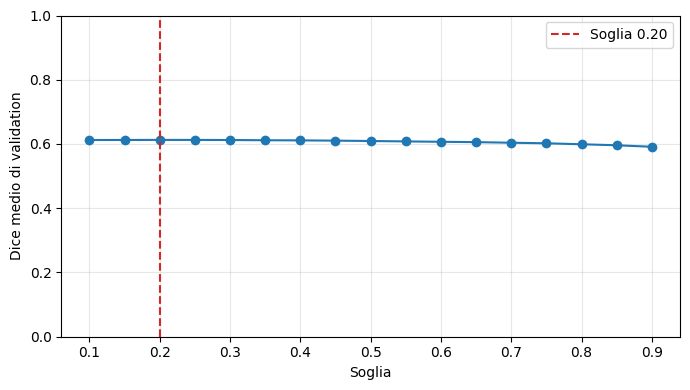

In [29]:
@torch.inference_mode()
def find_best_threshold(model, data_loader, device, thresholds=None, epsilon=1e-6):
    model.eval()
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    threshold_tensor = torch.as_tensor(thresholds, dtype=torch.float32, device=device)
    score_sums = torch.zeros_like(threshold_tensor)
    sample_count = 0

    progress_bar = tqdm(
        data_loader,
        desc="Ricerca soglia [validation]",
        unit="batch",
        leave=False,
    )
    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["mask"].to(device, non_blocking=True)
        probabilities = torch.sigmoid(model(images))

        predictions = (
            probabilities.unsqueeze(0)
            >= threshold_tensor.view(-1, 1, 1, 1, 1)
        )
        expanded_targets = targets.unsqueeze(0)
        dimensions = (2, 3, 4)
        intersection = (predictions * expanded_targets).sum(dim=dimensions)
        denominator = predictions.sum(dim=dimensions) + expanded_targets.sum(dim=dimensions)
        dice_per_sample = (2.0 * intersection + epsilon) / (denominator + epsilon)

        score_sums += dice_per_sample.sum(dim=1)
        sample_count += targets.shape[0]
        current_scores = score_sums / sample_count
        progress_bar.set_postfix(
            best_dice=f"{current_scores.max().item():.4f}",
        )

    mean_scores = score_sums / sample_count
    best_index = int(mean_scores.argmax().item())
    return {
        "thresholds": threshold_tensor.cpu().numpy(),
        "dice_scores": mean_scores.cpu().numpy(),
        "best_threshold": float(threshold_tensor[best_index].item()),
        "best_dice": float(mean_scores[best_index].item()),
    }


def plot_threshold_search(results, save_path=None):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    plt.plot(results["thresholds"], results["dice_scores"], marker="o")
    plt.axvline(results["best_threshold"], color="tab:red", linestyle="--", label=f"Soglia {results['best_threshold']:.2f}")
    plt.xlabel("Soglia")
    plt.ylabel("Dice medio di validation")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


best_threshold = 0.5
if "history" in globals() and history:
    tiled_results = evaluate_tiled(
        model, validation_samples, device,
        thresholds=np.arange(0.10, 0.91, 0.05),
        description="Ricerca soglia [validation]",
    )
    best_index = int(np.argmax(tiled_results["dice_resized"]))
    threshold_results = {
        "thresholds": tiled_results["thresholds"],
        "dice_scores": tiled_results["dice_resized"],
        "dice_native": tiled_results["dice_native"],
        "best_threshold": float(tiled_results["thresholds"][best_index]),
        "best_dice": float(tiled_results["dice_resized"][best_index]),
        "best_dice_native": float(tiled_results["dice_native"][best_index]),
    }
    best_threshold = threshold_results["best_threshold"]
    print(
        f"Soglia scelta sulla validation: {best_threshold:.2f} "
        f"(Dice={threshold_results['best_dice']:.4f})"
    )
    threshold_rows = [
        {
            "threshold": float(threshold),
            "validation_dice": float(score),
            "validation_dice_native": float(native_score),
        }
        for threshold, score, native_score in zip(
            threshold_results["thresholds"],
            threshold_results["dice_scores"],
            threshold_results["dice_native"],
        )
    ]
    save_json(
        {
            "best_threshold": threshold_results["best_threshold"],
            "best_validation_dice": threshold_results["best_dice"],
            "best_validation_dice_native": threshold_results["best_dice_native"],
            "scores": threshold_rows,
        },
        METRICS_DIR / "threshold_search.json",
    )
    with (METRICS_DIR / "threshold_search.csv").open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=("threshold", "validation_dice", "validation_dice_native"))
        writer.writeheader()
        writer.writerows(threshold_rows)
    plot_threshold_search(threshold_results, PLOTS_DIR / "threshold_search.png")
else:
    print("Ricerca non eseguita: in assenza di training resta valida la soglia predefinita 0.5.")

## Valutazione finale sul test interno

Il test interno deve essere consultato una sola volta, dopo aver concluso tutte le scelte su modello, iperparametri e soglia. Per questo motivo la valutazione è protetta dal flag `RUN_FINAL_TEST`, disattivato per impostazione predefinita.

Test interno a tasselli:   0%|          | 0/179 [00:00<?, ?img/s]

Test interno | loss=0.2147, Dice=0.6022, Dice nativo=0.6039, soglia=0.20, campioni=179


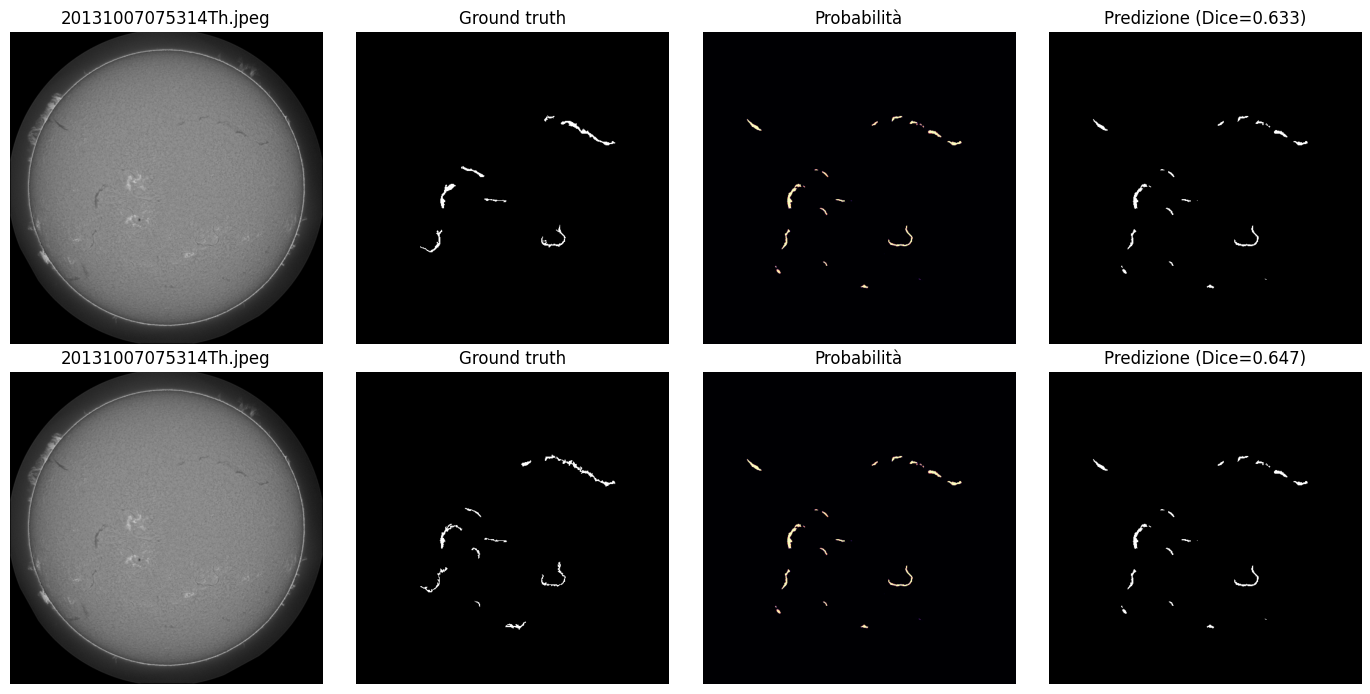

In [32]:
@torch.inference_mode()
def evaluate_model(model, data_loader, criterion, device, threshold):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_samples = 0

    progress_bar = tqdm(
        data_loader,
        desc=f"Test interno [soglia={threshold:.2f}]",
        unit="batch",
        leave=False,
    )
    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, masks)
        dice = binary_dice_score(logits, masks, threshold=threshold)

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_dice += dice.item() * batch_size
        total_samples += batch_size
        progress_bar.set_postfix(
            loss=f"{total_loss / total_samples:.4f}",
            dice=f"{total_dice / total_samples:.4f}",
        )

    return {
        "loss": total_loss / total_samples,
        "dice": total_dice / total_samples,
        "threshold": threshold,
        "samples": total_samples,
    }


# Il test interno resta nascosto fino alla selezione della configurazione finale.
RUN_FINAL_TEST = True

if RUN_FINAL_TEST:
    if "history" not in globals() or not history:
        raise RuntimeError("Eseguire il training prima della valutazione finale.")
    tiled_test = evaluate_tiled(
        model, test_samples, device,
        thresholds=(best_threshold,), description="Test interno a tasselli",
    )
    test_metrics = {
        "loss": tiled_test["loss"],
        "dice": float(tiled_test["dice_resized"][0]),
        "dice_native": float(tiled_test["dice_native"][0]),
        "threshold": best_threshold,
        "samples": len(test_samples),
    }
    print(
        f"Test interno | loss={test_metrics['loss']:.4f}, "
        f"Dice={test_metrics['dice']:.4f}, Dice nativo={test_metrics['dice_native']:.4f}, "
        f"soglia={test_metrics['threshold']:.2f}, campioni={test_metrics['samples']}"
    )
    save_json(test_metrics, METRICS_DIR / "test_metrics.json")
    display_images, display_masks, display_probabilities, display_names = [], [], [], []
    for sample in test_samples[:2]:
        image, mask = load_sample(sample)
        probability_map = predict_full_image_probability(model, image, device)
        display_image = Image.fromarray(image).convert("L").resize(
            (IMAGE_SIZE[1], IMAGE_SIZE[0]), resample=Image.Resampling.BILINEAR
        )
        display_images.append(
            torch.from_numpy(np.array(display_image, dtype=np.float32) / 255.0).unsqueeze(0)
        )
        display_masks.append(torch.from_numpy(resize_binary_mask(mask)).unsqueeze(0))
        display_probabilities.append(
            torch.from_numpy(resize_probability_map(probability_map)).unsqueeze(0)
        )
        display_names.append(sample["file_name"])
    test_prediction_batch = {
        "images": torch.stack(display_images),
        "masks": torch.stack(display_masks),
        "probabilities": torch.stack(display_probabilities),
        "file_names": display_names,
    }
    show_segmentation_predictions(
        test_prediction_batch,
        threshold=best_threshold,
        save_path=PLOTS_DIR / "test_predictions.png",
    )
else:
    print("Test interno non consultato (RUN_FINAL_TEST = False).")

## Archivio dell'esperimento

Questa cella consolida il riepilogo e il checkpoint del modello migliore. Può essere eseguita anche dopo una run già conclusa, purché `model` e `history` siano ancora presenti nel kernel.

In [31]:
if "history" in globals() and history:
    save_history(history)
    if "training_summary" in globals() and training_summary:
        best_epoch = training_summary["best_epoch"]
        best_validation_dice = training_summary["best_validation_dice"]
    else:
        best_history_row = max(history, key=lambda row: row["validation_dice"])
        best_epoch = best_history_row["epoch"]
        best_validation_dice = best_history_row["validation_dice"]
    checkpoint = {
        "epoch": best_epoch,
        "model_state_dict": {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        },
        "validation_dice": best_validation_dice,
        "best_threshold": best_threshold,
        "experiment_id": EXPERIMENT_ID,
    }
    torch.save(checkpoint, CHECKPOINTS_DIR / "best_model.pt")

    experiment_summary = {
        "experiment_id": EXPERIMENT_ID,
        "best_epoch": best_epoch,
        "best_validation_dice_at_0.5": best_validation_dice,
        "selected_threshold": best_threshold,
    }
    if "threshold_results" in globals():
        experiment_summary["validation_dice_at_selected_threshold"] = threshold_results["best_dice"]
    if "test_metrics" in globals():
        experiment_summary["test_metrics"] = test_metrics

    save_json(experiment_summary, EXPERIMENT_DIR / "summary.json")
    print(f"Esperimento archiviato in: {EXPERIMENT_DIR}")
else:
    print("Archivio non creato: non è presente una cronologia di training.")

Esperimento archiviato in: /content/experiments/04


## Sviluppi successivi

In base ai risultati valuteremo la ripetizione degli esperimenti con seed diversi e, per la submission Kaggle, test-time augmentation e rimozione delle componenti connesse piccole. La valutazione sul test interno della configurazione finale sarà eseguita una sola volta.